In [110]:
import pandas as pd
from sklearn.impute import SimpleImputer
from plotnine import *
from matplotlib import pyplot as plt
import numpy as np

import seaborn as sns
import tqdm as notebook_tqdm

# Set globally for all plots
plt.rcParams.update({
    "figure.figsize": (10, 6),   # width, height in inches
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('data/mimic-iv-bigquery-results-14052026.csv')

## Explore the Data for Missing Values

In [111]:
def plot_missing(df):
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    missing_pct = (missing / len(df) * 100).round(1)

    summary = pd.DataFrame({
        'missing_count': missing,
        'missing_pct':   missing_pct
    })

    # print(summary)

    # bin the data manually so we can colour by severity
    bins       = np.arange(0, 110, 20)
    bin_labels = [f'{int(b)}–{int(b+20)}%' for b in bins[:-1]]
    counts, _  = np.histogram(summary['missing_pct'], bins=bins)
    bin_starts = bins[:-1]  # [0, 20, 40, 60, 80]

    df_missing = pd.DataFrame({
        'bin':   pd.Categorical(bin_labels, categories=bin_labels, ordered=True),
        'count': counts,
        'group': ['High ≥ 80%'       if start >= 80 else
                'Moderate 40–80%'  if start >= 40 else
                'Low < 40%'
                for start in bin_starts]
    })

    missingness_plot = (
        ggplot(df_missing, aes(x='bin', y='count', fill='group'))
        + geom_col(width=0.8, color='white', size=0.5)
        + geom_text(aes(label='count'), va='bottom', nudge_y=0.15, size=10, fontweight='bold')
        + scale_fill_manual(
            name   = 'Missingness',
            values = {
                'Low < 40%':       '#2ecc71',
                'Moderate 40–80%': '#f39c12',
                'High ≥ 80%':      '#e74c3c',
            },
            breaks = ['Low < 40%', 'Moderate 40–80%', 'High ≥ 80%']
        )
        + scale_y_continuous(expand=(0, 0), limits=(0, max(counts) + 3))
        + labs(
            x     = 'Missing value %',
            y     = 'Number of columns',
            title = 'Distribution of missingness across lab feature columns'
        )
        + theme_minimal()
        + theme(
            axis_text_x      = element_text(size=10),
            panel_grid_major_x = element_blank(),
            panel_grid_minor   = element_blank(),
            plot_title         = element_text(size=13, weight='bold'),
            legend_title       = element_text(size=10),
            figure_size        = (10, 5),
        )
    )
    missingness_plot.save('missing_histogram_after_100.png', dpi=150)

    return missingness_plot


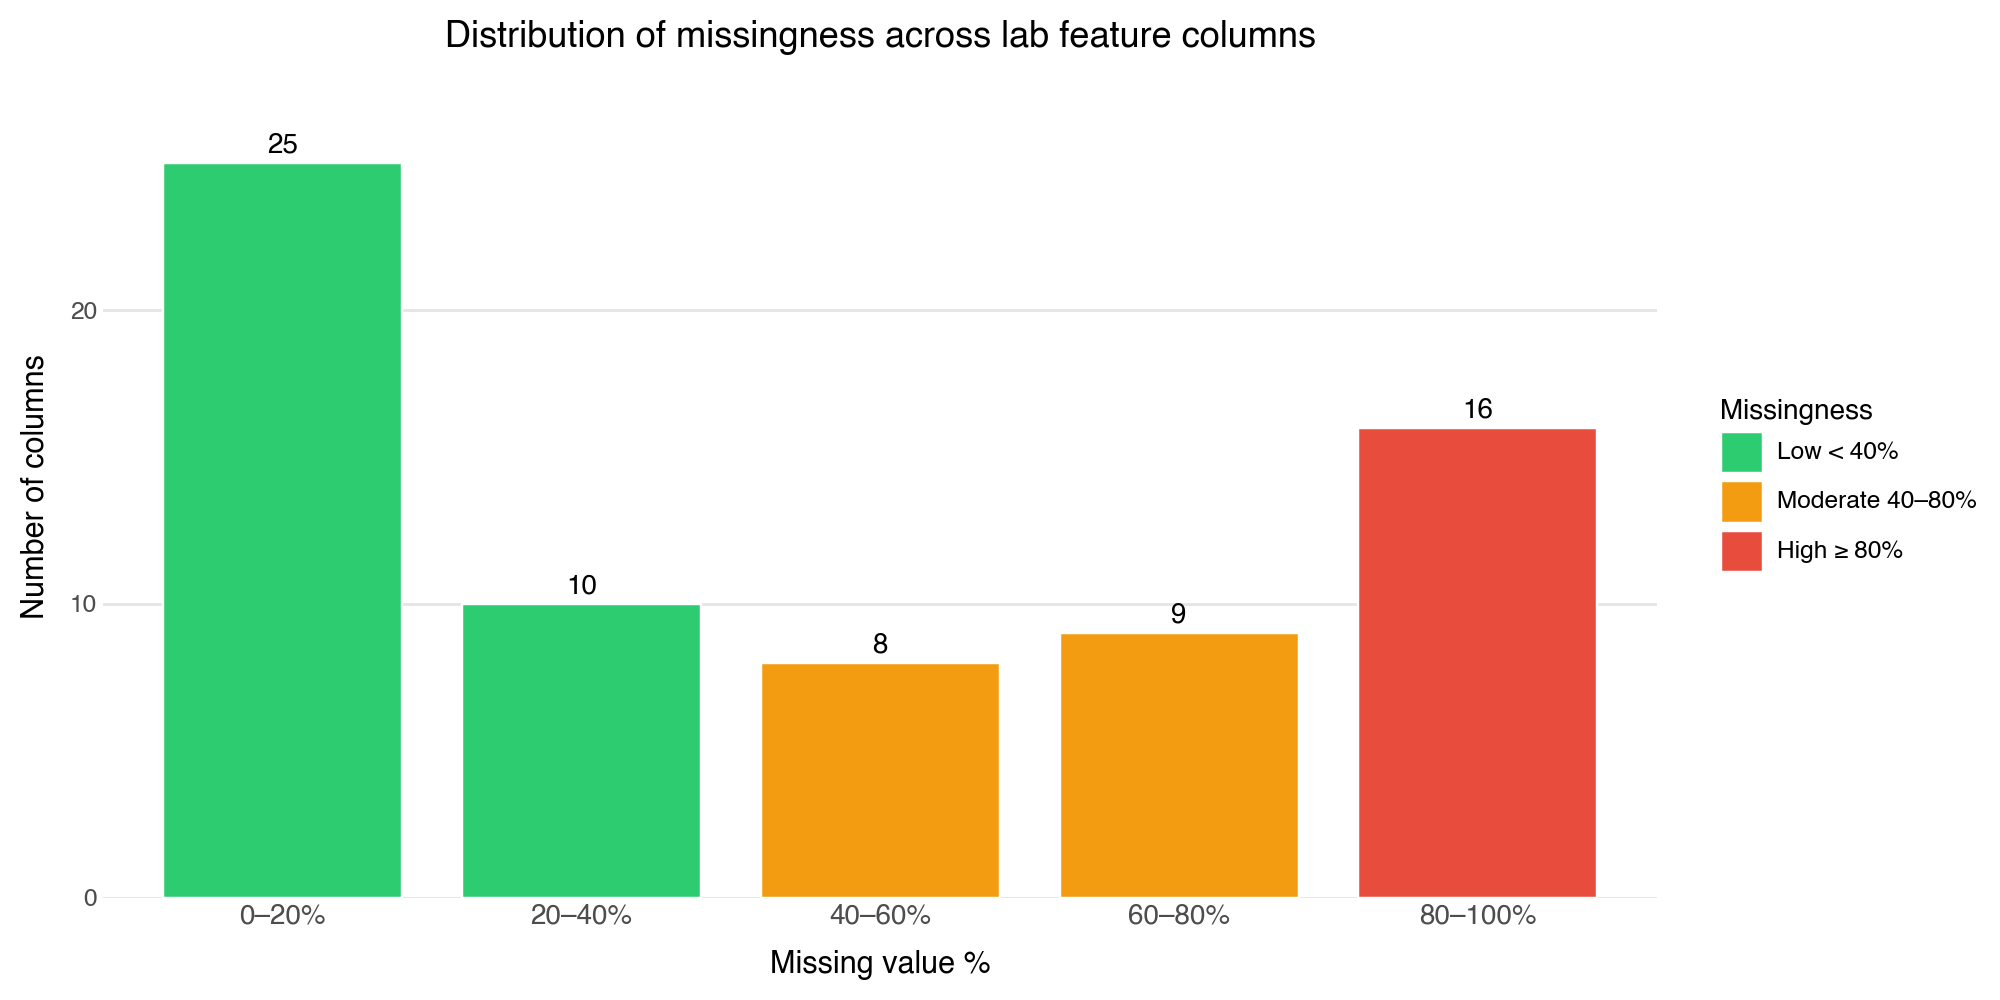

In [112]:
plot_missing(df)

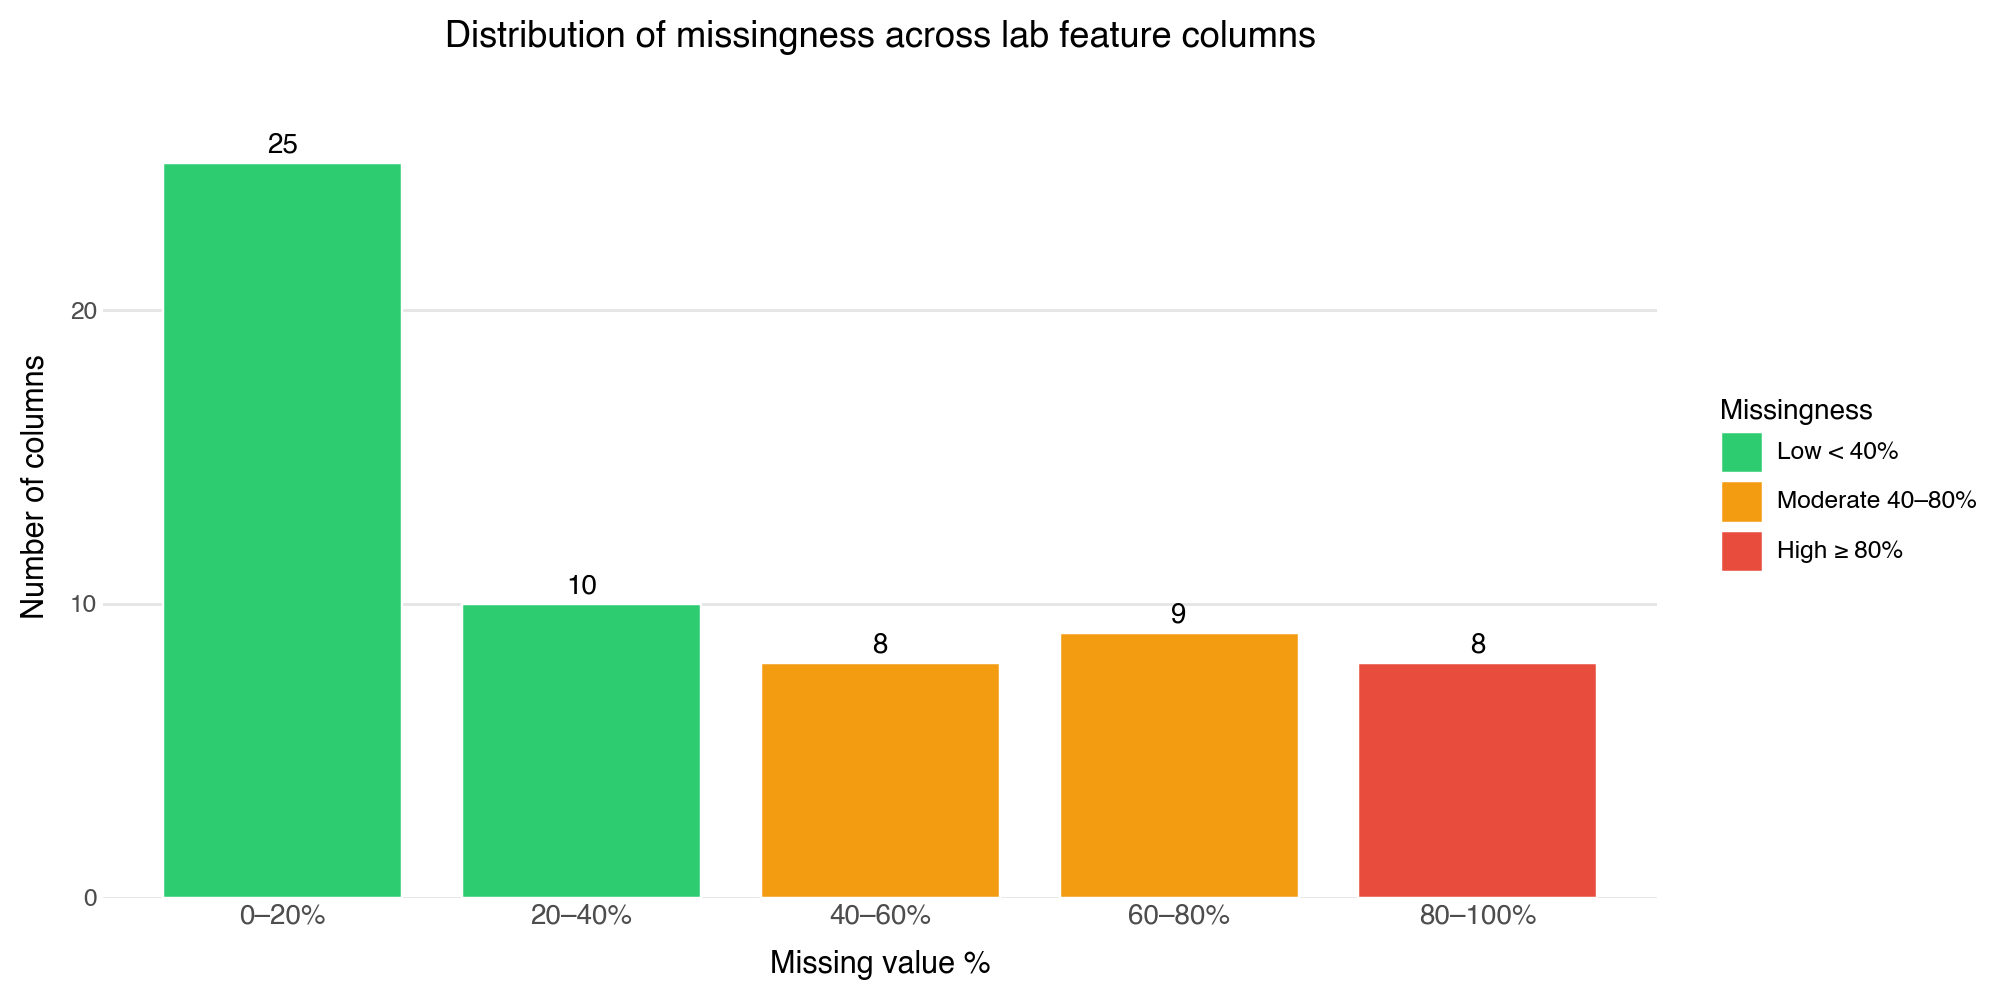

In [113]:
#Removing all the columns that have 100% missing values
cols_to_drop = df.columns[df.isna().mean() == 1].tolist()
df = df.drop(columns=cols_to_drop)

plot_missing(df)

## Imputing the Missing Values

In [ ]:
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score
from sklearn.model_selection import train_test_split

In [115]:
DROP_COLS  = ['subject_id', 'hadm_id', 'organisms_cultured', 'specimen_types', 'gender', 'race', 'insurance','admission_type']
CAT_COLS   = []
LAB_COLS = [c for c in df.columns
            if c.endswith('_first') or c.endswith('_max')]
TARGET_COL = 'had_resistance'

In [116]:
for col in LAB_COLS:
    df[f'{col}_missing'] = df[col].isna().astype(int)

In [117]:
df = pd.get_dummies(df, columns=CAT_COLS, drop_first=True)
df = df.drop(columns=DROP_COLS)

In [122]:
df[TARGET_COL].value_counts()

had_resistance
0    174738
1     23771
Name: count, dtype: int64

In [120]:
df_balanced = pd.concat([
    df[df[TARGET_COL] == 0].sample(20000, random_state=42),
    df[df[TARGET_COL] == 1].sample(20000, random_state=42)
]).reset_index(drop=True)

In [ ]:
X = df_balanced.drop(columns=[TARGET_COL])
y = df_balanced[TARGET_COL]

In [ ]:
# See what's still non-numeric
print(X.select_dtypes(exclude='number').dtypes)

Series([], dtype: object)


In [ ]:
median_imputer = SimpleImputer(strategy='median')
X_median = pd.DataFrame(
    median_imputer.fit_transform(X),
    columns=median_imputer.get_feature_names_out()
)

mice_imputer = IterativeImputer(max_iter=10, random_state=42)
X_mice = pd.DataFrame(
    mice_imputer.fit_transform(X),
    columns=mice_imputer.get_feature_names_out()
)

X_median.to_csv('data/features_imputed_median.csv')
X_mice.to_csv('data/features_imputed_mice.csv')
y.to_csv('data/target.csv')